In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from keras.models import load_model
from keras.utils import plot_model
from keras.models import Model
import tensorflow_decision_forests as tfdf
import math
import warnings
import sklearn.metrics as metrics
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.svm import SVR

warnings.filterwarnings("ignore")

In [2]:
# Processing Data

def process_data(train, test, lags):
    """Process data
    Reshape and split train\test data.

    # Arguments
        train: String, name of .csv train file.
        test: String, name of .csv test file.
        lags: integer, time lag.
    # Returns
        X_train: ndarray.
        y_train: ndarray.
        X_test: ndarray.
        y_test: ndarray.
        scaler: StandardScaler.
    """
    attr = 'Lane 1 Flow (Veh/5 Minutes)'
    df1 = pd.read_csv(train, encoding='utf-8').fillna(0)
    df2 = pd.read_csv(test, encoding='utf-8').fillna(0)

    # scaler = StandardScaler().fit(df1[attr].values)
    scaler = MinMaxScaler(feature_range=(0, 1)).fit(df1[attr].values.reshape(-1, 1))
    flow1 = scaler.transform(df1[attr].values.reshape(-1, 1)).reshape(1, -1)[0]
    flow2 = scaler.transform(df2[attr].values.reshape(-1, 1)).reshape(1, -1)[0]

    train, test = [], []
    for i in range(lags, len(flow1)):
        train.append(flow1[i - lags: i + 1])
    for i in range(lags, len(flow2)):
        test.append(flow2[i - lags: i + 1])

    train = np.array(train)
    test = np.array(test)
    np.random.shuffle(train)

    X_train = train[:, :-1]
    y_train = train[:, -1]
    X_test = test[:, :-1]
    y_test = test[:, -1]

    return X_train, y_train, X_test, y_test, scaler


In [3]:
def MAPE(y_true, y_pred):
    """Mean Absolute Percentage Error
    Calculate the mape.

    # Arguments
        y_true: List/ndarray, ture data.
        y_pred: List/ndarray, predicted data.
    # Returns
        mape: Double, result data for train.
    """

    y = [x for x in y_true if x > 0]
    y_pred = [y_pred[i] for i in range(len(y_true)) if y_true[i] > 0]

    num = len(y_pred)
    sums = 0

    for i in range(num):
        tmp = abs(y[i] - y_pred[i]) / y[i]
        sums += tmp

    mape = sums * (100 / num)

    return mape

def eva_regress(y_true, y_pred):
    """Evaluation
    evaluate the predicted resul.

    # Arguments
        y_true: List/ndarray, ture data.
        y_pred: List/ndarray, predicted data.
    """

    mape = MAPE(y_true, y_pred)
    vs = metrics.explained_variance_score(y_true, y_pred)
    mae = metrics.mean_absolute_error(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    r2 = metrics.r2_score(y_true, y_pred)
    print('explained_variance_score:%f' % vs)
    print('mape:%f%%' % mape)
    print('mae:%f' % mae)
    print('mse:%f' % mse)
    print('rmse:%f' % math.sqrt(mse))
    print('r2:%f' % r2)

In [4]:
def plot_results(y_true, y_preds, names):
    """Plot
    Plot the true data and predicted data.

    # Arguments
        y_true: List/ndarray, ture data.
        y_pred: List/ndarray, predicted data.
        names: List, Method names.
    """
    d = '2016-3-4 00:00'
    x = pd.date_range(d, periods=288, freq='5min')

    fig = plt.figure()
    ax = fig.add_subplot(111)

    ax.plot(x, y_true, label='True Data')
    for name, y_pred in zip(names, y_preds):
        ax.plot(x, y_pred, label=name)

    plt.legend()
    plt.grid(True)
    plt.xlabel('Time of Day')
    plt.ylabel('Flow')

    date_format = mpl.dates.DateFormatter("%H:%M")
    ax.xaxis.set_major_formatter(date_format)
    fig.autofmt_xdate()

    plt.show()

### Deep Learning Models

In [5]:
"""
Defination of NN model
"""
from keras.layers import Dense, Dropout, Activation
from keras.layers import LSTM, GRU
from keras.models import Sequential


def get_lstm(units):
    """LSTM(Long Short-Term Memory)
    Build LSTM Model.

    # Arguments
        units: List(int), number of input, output and hidden units.
    # Returns
        model: Model, nn model.
    """

    model = Sequential()
    model.add(LSTM(units[1], input_shape=(units[0], 1), return_sequences=True))
    model.add(LSTM(units[2]))
    model.add(Dropout(0.2))
    model.add(Dense(units[3], activation='sigmoid'))

    return model


def get_gru(units):
    """GRU(Gated Recurrent Unit)
    Build GRU Model.

    # Arguments
        units: List(int), number of input, output and hidden units.
    # Returns
        model: Model, nn model.
    """

    model = Sequential()
    model.add(GRU(units[1], input_shape=(units[0], 1), return_sequences=True))
    model.add(GRU(units[2]))
    model.add(Dropout(0.2))
    model.add(Dense(units[3], activation='sigmoid'))

    return model


def _get_sae(inputs, hidden, output):
    """SAE(Auto-Encoders)
    Build SAE Model.

    # Arguments
        inputs: Integer, number of input units.
        hidden: Integer, number of hidden units.
        output: Integer, number of output units.
    # Returns
        model: Model, nn model.
    """

    model = Sequential()
    model.add(Dense(hidden, input_dim=inputs, name='hidden'))
    model.add(Activation('sigmoid'))
    model.add(Dropout(0.2))
    model.add(Dense(output, activation='sigmoid'))

    return model


def get_saes(layers):
    """SAEs(Stacked Auto-Encoders)
    Build SAEs Model.

    # Arguments
        layers: List(int), number of input, output and hidden units.
    # Returns
        models: List(Model), List of SAE and SAEs.
    """
    sae1 = _get_sae(layers[0], layers[1], layers[-1])
    sae2 = _get_sae(layers[1], layers[2], layers[-1])
    sae3 = _get_sae(layers[2], layers[3], layers[-1])

    saes = Sequential()
    saes.add(Dense(layers[1], input_dim=layers[0], name='hidden1'))
    saes.add(Activation('sigmoid'))
    saes.add(Dense(layers[2], name='hidden2'))
    saes.add(Activation('sigmoid'))
    saes.add(Dense(layers[3], name='hidden3'))
    saes.add(Activation('sigmoid'))
    saes.add(Dropout(0.2))
    saes.add(Dense(layers[4], activation='sigmoid'))

    models = [sae1, sae2, sae3, saes]

    return models

def train_model(model, X_train, y_train, name, config):
    """train
    train a single model.

    # Arguments
        model: Model, NN model to train.
        X_train: ndarray(number, lags), Input data for train.
        y_train: ndarray(number, ), result data for train.
        name: String, name of model.
        config: Dict, parameter for train.
    """

    model.compile(loss="mse", optimizer="rmsprop", metrics=["mape"])
    # early = EarlyStopping(monitor='val_loss', patience=30, verbose=0, mode='auto')
    hist = model.fit(
        X_train,
        y_train,
        batch_size=config["batch"],
        epochs=config["epochs"],
        validation_split=0.05,
    )

    model.save("model/" + name + ".keras")
    df = pd.DataFrame.from_dict(hist.history)
    df.to_csv("model/" + name + " loss.csv", encoding="utf-8", index=False)


def train_random_forest(x,y,X_test,y_test,scaler):

    # train_df = pd.read_csv(train)
    # print(train_df)
    # train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_df,task=tfdf.keras.Task.REGRESSION, label= 'Lane 1 Flow (Veh/5 Minutes)',in_place=1)
    model = tfdf.keras.RandomForestModel(task=tfdf.keras.Task.REGRESSION)
    model.fit(x,y)
    model.save("model/rf.keras")
    y_preds = []
    predicted = model.predict(X_test)
    predicted = model.predict(X_test)
    predicted = scaler.inverse_transform(predicted.reshape(-1, 1)).reshape(1, -1)[0]
    y_preds.append(predicted[:288])
    eva_regress(y_test, predicted)
    plot_results(y_test[: 288], y_preds, ['Random Forests'])


def train_seas(models, X_train, y_train, name, config):
    """train
    train the SAEs model.

    # Arguments
        models: List, list of SAE model.
        X_train: ndarray(number, lags), Input data for train.
        y_train: ndarray(number, ), result data for train.
        name: String, name of model.
        config: Dict, parameter for train.
    """

    temp = X_train
    # early = EarlyStopping(monitor='val_loss', patience=30, verbose=0, mode='auto')

    for i in range(len(models) - 1):
        if i > 0:
            p = models[i - 1]
            hidden_layer_model = Model(
                input=p.input, output=p.get_layer("hidden").output
            )
            temp = hidden_layer_model.predict(temp)

        m = models[i]
        m.compile(loss="mse", optimizer="rmsprop", metrics=["mape"])

        m.fit(
            temp,
            y_train,
            batch_size=config["batch"],
            epochs=config["epochs"],
            validation_split=0.05,
        )

        models[i] = m

    saes = models[-1]
    for i in range(len(models) - 1):
        weights = models[i].get_layer("hidden").get_weights()
        saes.get_layer("hidden%d" % (i + 1)).set_weights(weights)

    train_model(saes, X_train, y_train, name, config)


In [6]:
lag = 12
config = {"batch": 256, "epochs": 100}
file1 = "data/train.csv"
file2 = "data/test.csv"

### Random Forest Model

In [7]:
X_train, y_train, X_test, y_test, scaler = process_data(file1, file2, lag)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(1, -1)[0]

mod = tfdf.keras.RandomForestModel(task=tfdf.keras.Task.REGRESSION)
mod.fit(X_train,y_train)
y_preds = []
predicted = mod.predict(X_test)
predicted_rf = scaler.inverse_transform(predicted.reshape(-1, 1)).reshape(1, -1)[0]
y_preds.append(predicted_rf[:288])
eva_regress(y_test, predicted_rf)

Use /var/folders/0_/jlz3w3sd0rvgpp49r0h93j_c0000gn/T/tmpe_35st9a as temporary training directory
Reading training dataset...


2024-04-22 18:35:09.114259: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2024-04-22 18:35:09.114283: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2024-04-22 18:35:09.114307: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2024-04-22 18:35:09.114487: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-04-22 18:35:09.114507: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2024-04-22 18:35:11.478572: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Training dataset read in 0:00:02.866107. Found 7764 examples.
Training model...


[INFO 24-04-22 18:35:13.5703 IST kernel.cc:1233] Loading model from path /var/folders/0_/jlz3w3sd0rvgpp49r0h93j_c0000gn/T/tmpe_35st9a/model/ with prefix eac834d11e3c483b


Model trained in 0:00:02.217932
Compiling model...


[INFO 24-04-22 18:35:14.3393 IST decision_forest.cc:734] Model loaded with 300 root(s), 607140 node(s), and 12 input feature(s).
[INFO 24-04-22 18:35:14.3394 IST abstract_model.cc:1344] Engine "RandomForestOptPred" built
[INFO 24-04-22 18:35:14.3394 IST kernel.cc:1061] Use fast generic engine


Model compiled.
135/135 [==============================] - 1s 4ms/step
explained_variance_score:0.945086
mape:18.001021%
mae:6.936971
mse:89.211247
rmse:9.445171
r2:0.945082


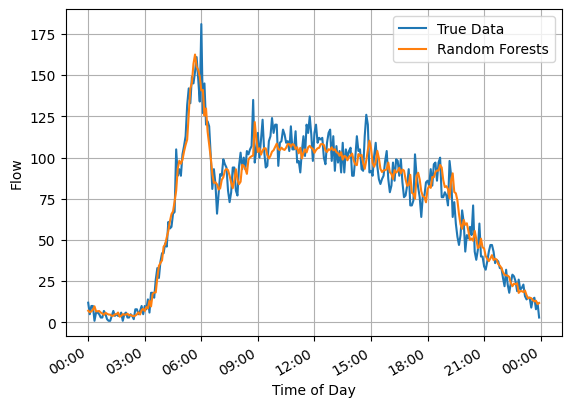

In [8]:
plot_results(y_test[: 288], [predicted_rf[:288]], ['Random Forests'])

### LSTM

In [9]:
X_train, y_train, X_test, y_test, scaler = process_data(file1, file2, lag)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(1, -1)[0]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
m = get_lstm([12, 64, 64, 1])
train_model(m, X_train, y_train,'lstm', config)
lstm = load_model('model/lstm.keras')
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted = lstm.predict(X_test)
predicted_lstm = scaler.inverse_transform(predicted.reshape(-1, 1)).reshape(1, -1)[0]
y_preds.append(predicted_lstm[:288])
eva_regress(y_test, predicted_lstm)  

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0520 - mape: 518632.6250 - val_loss: 0.0138 - val_mape: 106.3553
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0116 - mape: 44461.2148 - val_loss: 0.0123 - val_mape: 103.7049
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0106 - mape: 127264.7734 - val_loss: 0.0111 - val_mape: 88.1922
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0102 - mape: 83832.3047 - val_loss: 0.0105 - val_mape: 94.1423
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0091 - mape: 126674.4609 - val_loss: 0.0099 - val_mape: 69.1095
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0089 - mape: 43562.0430 - val_loss: 0.0097 - val_mape: 75.6263
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0083 - mape: 50843.3633 - val_loss: 0.0088 - val_mape: 68.7710
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0078 - mape: 81329.5312 - val_loss: 0.0079 - val_mape: 65.

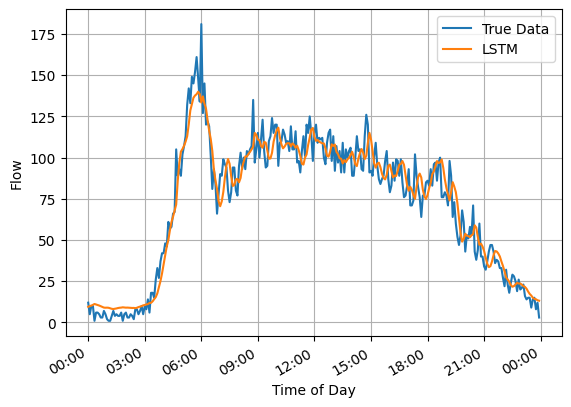

In [10]:
plot_results(y_test[: 288], [predicted_lstm[:288]], ['LSTM'])

### SVR

In [11]:
# from sklearn.svm import SVR
X_train, y_train, X_test, y_test, scaler = process_data(file1, file2, lag)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(1, -1)[0]
regressor = SVR(kernel = 'rbf')
regressor.fit(X_train,y_train)

predicted = regressor.predict(X_test)
predicted_svr = scaler.inverse_transform(predicted.reshape(-1, 1)).reshape(1, -1)[0]
y_preds.append(predicted_svr[:288])
eva_regress(y_test, predicted_svr)  

explained_variance_score:0.931465
mape:51.863408%
mae:8.661777
mse:116.870264
rmse:10.810655
r2:0.928055


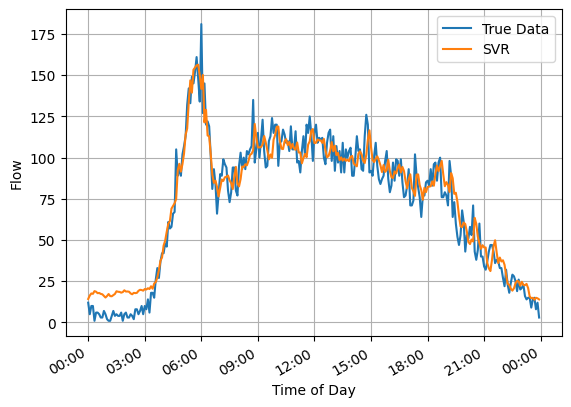

In [12]:
plot_results(y_test[: 288], [predicted_svr[:288]], ['SVR'])

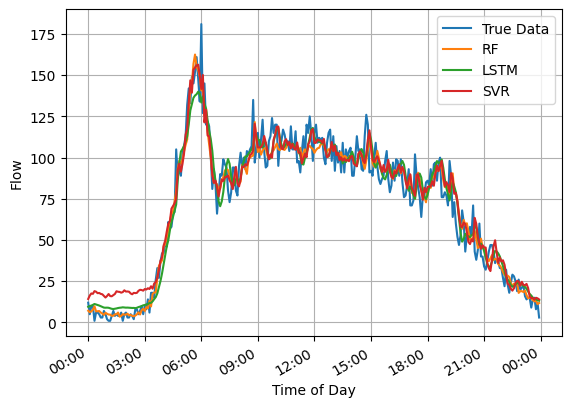

In [13]:
plot_results(y_test[: 288], y_preds, ['RF', 'LSTM','SVR'])